# Import các thư viện cần thiết

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.regularizers import l2
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Tải lên dữ liệu

In [4]:
df = pd.read_csv('PNJ.csv')

In [5]:
df.head()

,Ticker,Date/Time,Open,High,Low,Close,Volume,Open Interest
0,PNJ,2/28/2018 9:15,78.14,78.99,78.14,78.99,270,0
1,PNJ,2/28/2018 9:16,78.94,78.94,78.94,78.94,10,0
2,PNJ,2/28/2018 9:19,78.14,78.14,78.14,78.14,283,0
3,PNJ,2/28/2018 9:20,78.14,78.14,78.14,78.14,480,0
4,PNJ,2/28/2018 9:21,78.14,78.14,78.14,78.14,146,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125309 entries, 0 to 125308
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Ticker         125309 non-null  object 
 1   Date/Time      125309 non-null  object 
 2   Open           125309 non-null  float64
 3   High           125309 non-null  float64
 4   Low            125309 non-null  float64
 5   Close          125309 non-null  float64
 6   Volume         125309 non-null  int64  
 7   Open Interest  125309 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 7.6+ MB


In [7]:
df.describe()

,Open,High,Low,Close,Volume,Open Interest
count,125309.000000,125309.000000,125309.000000,125309.000000,125309.000000,125309.0
mean,72.182052,72.372590,72.042287,72.179371,3031.830451,0.0
std,9.900263,9.995786,9.830847,9.899401,7248.952968,0.0
min,44.430000,44.530000,44.040000,44.140000,1.000000,0.0
25%,64.600000,64.700000,64.570000,64.600000,220.000000,0.0
50%,72.800000,73.010000,72.640000,72.830000,1000.000000,0.0
75%,80.160000,80.350000,80.060000,80.160000,3130.000000,0.0
max,100.160000,100.160000,100.160000,100.160000,580730.000000,0.0


# Làm sạch dữ liệu

In [8]:
df = df.drop('Ticker', axis=1)
df = df.drop('Open Interest', axis=1)

In [9]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M')

# Trực quan hóa dữ liệu

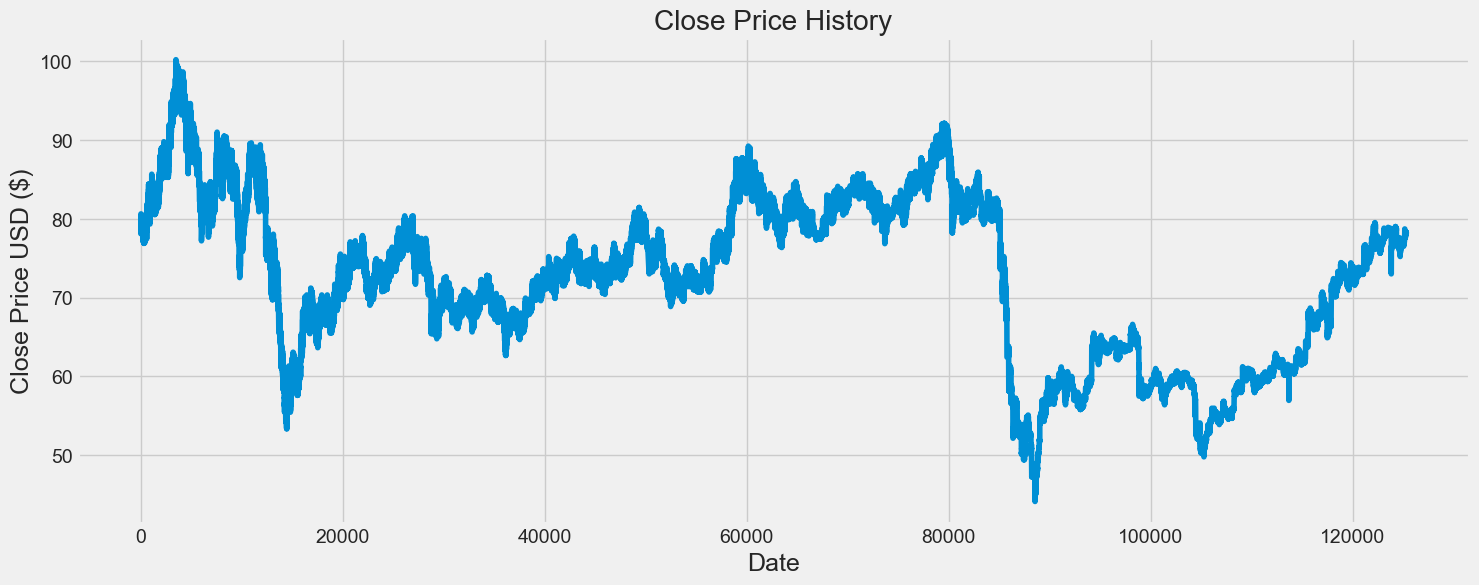

In [10]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

# Tiền xử lý dữ liệu

+ Lấy trung bình dữ liệu theo giờ để làm phẳng data và dễ dàng fill những data còn thiếu

In [11]:
df.set_index('Date/Time', inplace=True)

df = df.resample('H').mean()

In [12]:
df.describe()

,Open,High,Low,Close,Volume
count,3543.000000,3543.000000,3543.000000,3543.000000,3543.000000
mean,72.427159,72.609333,72.292627,72.424769,2881.761618
std,9.657133,9.741983,9.598704,9.656204,2628.628555
min,45.719483,45.859138,45.582069,45.692241,11.933333
25%,66.309144,66.477876,66.175613,66.327992,1357.341667
50%,72.787500,72.951429,72.656667,72.792857,2191.785714
75%,80.268541,80.441854,80.149491,80.263079,3571.944444
max,97.590385,97.849615,97.343077,97.521538,40720.000000


In [13]:
df.isnull().sum()

Open      21135
High      21135
Low       21135
Close     21135
Volume    21135
dtype: int64

+ Lấp vào những data còn thiếu để có thể sử dụng các model time-series

In [14]:
df.interpolate(method='linear', inplace=True)  
df.ffill(inplace=True) 

In [15]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

+ Chia data thành tập dự đoán và tập dữ liệu dùng để dự đoán để dễ dàng inverse scale

In [16]:
df_X = df.reset_index()[['Open', 'High', 'Low', 'Close', 'Volume']]


In [17]:
df_X

,Open,High,Low,Close,Volume
0,78.755946,78.886216,78.615135,78.705946,106.297297
1,78.657750,78.716000,78.629250,78.693500,75.925000
2,78.795000,78.806875,78.789375,78.801250,74.250000
3,78.783152,78.795714,78.776449,78.789860,75.549242
4,78.771303,78.784553,78.763523,78.778470,76.848485
...,...,...,...,...,...
24673,78.203636,78.249091,78.172727,78.220000,7462.727273
24674,78.041379,78.058621,78.034483,78.048276,1590.689655
24675,78.035996,78.049719,78.022343,78.035362,2320.038705
24676,78.030612,78.040816,78.010204,78.022449,3049.387755


+ Data được dùng để dự đoán sẽ là data close sau time step sử dụng dữ liệu của các time-step trước đó

In [18]:
df_y = df.reset_index()['Close']

In [19]:
df_y

0        78.705946
1        78.693500
2        78.801250
3        78.789860
4        78.778470
           ...    
24673    78.220000
24674    78.048276
24675    78.035362
24676    78.022449
24677    78.216000
Name: Close, Length: 24678, dtype: float64

+ Mô hình được chọn là LSTM, vì nó có khả năng làm việc với dữ liệu trong theo thời gian rất tốt. Ngoài ra chúng ta còn có thể chọn ARIMA, tuy nhiên với dataset lớn và phức tạp như giá cổ phiếu, ARIMA sẽ không hoạt động tốt. Vì LSTM rất nhạy cảm với quy mô dữ liệu, chúng ta sẽ sử dụng MinMaxScaler.

+ Chúng ta phải chia thành 2 scaler ( một cho tập dữ liệu đầu vào và 1 tập dữ liệu đầu ra ) để có thể inverse scale mà không bị lỗi chiều dữ liệu

In [20]:
scaler1 = MinMaxScaler(feature_range=(0,4))  
df_X = scaler1.fit_transform(np.array(df_X).reshape(-1, 5))

In [21]:
scaler2 = MinMaxScaler(feature_range=(0,1))   
df_y = scaler2.fit_transform(np.array(df_y).reshape(-1, 1))

In [22]:
df_X

array([[2.54759119, 2.54100981, 2.55273747, 2.54787978, 0.00927226],
       [2.54001886, 2.52791385, 2.55382825, 2.54691925, 0.00628786],
       [2.55060283, 2.53490552, 2.56620242, 2.55523501, 0.00612327],
       ...,
       [2.49207258, 2.47665205, 2.50692757, 2.49612654, 0.22679587],
       [2.49165743, 2.47596714, 2.50598946, 2.49512993, 0.29846216],
       [2.50502814, 2.49036852, 2.52065656, 2.51006751, 0.25013879]])

In [23]:
df_y

array([[0.63696995],
       [0.63672981],
       [0.63880875],
       ...,
       [0.62403164],
       [0.62378248],
       [0.62751688]])

In [24]:
data = np.concatenate([df_X, df_y], axis=1)

In [25]:
data

array([[2.54759119, 2.54100981, 2.55273747, 2.54787978, 0.00927226,
        0.63696995],
       [2.54001886, 2.52791385, 2.55382825, 2.54691925, 0.00628786,
        0.63672981],
       [2.55060283, 2.53490552, 2.56620242, 2.55523501, 0.00612327,
        0.63880875],
       ...,
       [2.49207258, 2.47665205, 2.50692757, 2.49612654, 0.22679587,
        0.62403164],
       [2.49165743, 2.47596714, 2.50598946, 2.49512993, 0.29846216,
        0.62378248],
       [2.50502814, 2.49036852, 2.52065656, 2.51006751, 0.25013879,
        0.62751688]])

+ Tạo dataset để train time-series model

In [26]:
training_size = int(len(data)*0.75)
test_size = len(data) - training_size
train_data_X = df_X[:training_size, :]
test_data_X = df_X[training_size:, :]
train_data_y = df_y[:training_size, :]
test_data_y = df_y[training_size:, :]

In [27]:
train_data_X.shape, test_data_X.shape

((18508, 5), (6170, 5))

In [28]:
def create_dataset(df_x, df_y, time_step=1):
    dataX, dataY = [], []
    for i in range(len(df_y) - time_step - 1):
        a = df_x[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(df_y[i + time_step, -1])
    return np.array(dataX), np.array(dataY)

In [29]:
time_step = 100,
X_train, y_train = create_dataset(train_data_X, train_data_y, time_step[0])
X_test, y_test = create_dataset(test_data_X, test_data_y, time_step[0])

In [30]:
y_train = y_train.reshape(-1,1 )
y_test = y_test.reshape(-1,1 )

In [31]:
X_train 

array([[[2.54759119, 2.54100981, 2.55273747, 2.54787978, 0.00927226],
        [2.54001886, 2.52791385, 2.55382825, 2.54691925, 0.00628786],
        [2.55060283, 2.53490552, 2.56620242, 2.55523501, 0.00612327],
        ...,
        [2.4625386 , 2.44853369, 2.47732717, 2.46820176, 0.01238821],
        [2.46268116, 2.44867882, 2.47745328, 2.46832855, 0.01228969],
        [2.46282372, 2.44882394, 2.4775794 , 2.46845533, 0.01219117]],

       [[2.54001886, 2.52791385, 2.55382825, 2.54691925, 0.00628786],
        [2.55060283, 2.53490552, 2.56620242, 2.55523501, 0.00612327],
        [2.54968914, 2.53404683, 2.56520352, 2.55435596, 0.00625094],
        ...,
        [2.46268116, 2.44867882, 2.47745328, 2.46832855, 0.01228969],
        [2.46282372, 2.44882394, 2.4775794 , 2.46845533, 0.01219117],
        [2.46296628, 2.44896907, 2.47770551, 2.46858211, 0.01209265]],

       [[2.55060283, 2.53490552, 2.56620242, 2.55523501, 0.00612327],
        [2.54968914, 2.53404683, 2.56520352, 2.55435596, 0.0

In [32]:
y_train

array([[0.61714553],
       [0.61717722],
       [0.61720892],
       ...,
       [0.2272199 ],
       [0.23177878],
       [0.23720109]])

In [33]:
X_test.shape, y_test.shape

((6069, 100, 5), (6069, 1))

In [34]:
print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(18407, 100, 5)
(18407, 1)
(6069, 100, 5)
(6069, 1)


(None, None)

# Tạo model Stacked LSTM

30 30 30 0.3 0.01 100 epochs

In [35]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(40, return_sequences=True, input_shape=(time_step[0], 5)),
    tf.keras.layers.Dropout(0.3),  
    
    tf.keras.layers.LSTM(40, return_sequences=True),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.LSTM(40),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\phana\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

batch_size = 64
train_dataset = train_dataset.batch(batch_size).repeat()  
test_dataset = test_dataset.batch(batch_size)

+ Chọn số vòng lặp = 100 vì sau khi đánh giá model ta thấy từ sau vòng lặp 100 lỗi của mô hình sẽ tăng dần.

In [37]:
history = ( 
    model.fit(train_dataset, 
          validation_data=(X_test,y_test), 
          epochs=100, 
          steps_per_epoch=len(X_train) // batch_size, 
          verbose=1)
)

Epoch 1/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - loss: 0.0274 - val_loss: 0.0380
Epoch 2/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - loss: 0.0180 - val_loss: 0.0097
Epoch 3/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - loss: 0.0289 - val_loss: 0.0090
Epoch 4/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - loss: 0.0276 - val_loss: 0.0011
Epoch 5/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.0121 - val_loss: 0.0021
Epoch 6/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - loss: 0.0107 - val_loss: 6.2012e-04
Epoch 7/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.0091 - val_loss: 6.2539e-04
Epoch 8/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - loss: 0.0097 - val_loss: 3.9332e-04
Epoch 9/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - loss: 0.0087 - val_loss: 9.6231e-05
Epoch 10/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - loss: 0.0074 - val_loss: 2.2786e-04
Epoch 11/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.0073 - val_loss: 2.7245

# Đánh giá model

+ Chúng ta cần xét loss của model qua mỗi epoch để có thể dừng train sớm, giảm thiểu tối đa loss

In [38]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

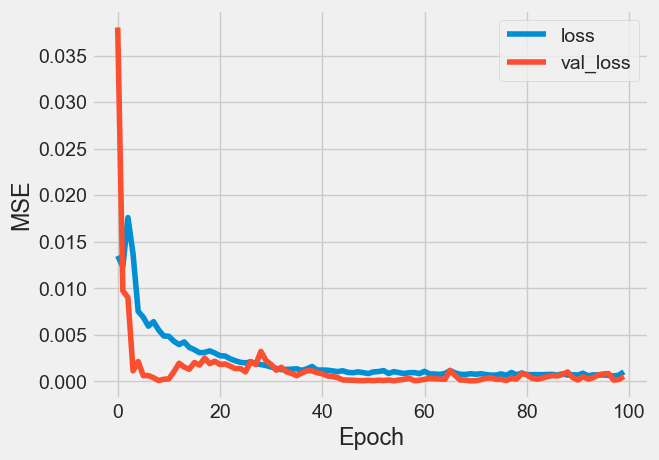

In [39]:
plot_loss(history)

+ Tiếp theo chúng ta cần đánh giá độ chính xác của dự đoán

In [40]:
predictions_scaled = model.predict(X_test)
predictions_scaled = predictions_scaled.reshape(-1,1)

predictions_train = model.predict(X_train)  
predictions_train = predictions_train.reshape(-1,1)

190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
576/576 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


In [41]:
predictions = scaler2.inverse_transform(predictions_scaled)
predictions_train = scaler2.inverse_transform(predictions_train)
y_test = scaler2.inverse_transform(y_test)
y_train = scaler2.inverse_transform(y_train)

In [42]:
column_names_pred = ['Close_predict']
df_predictions = pd.DataFrame(predictions, columns=column_names_pred)

df_test = pd.DataFrame(y_test)

In [43]:
df_predictions

,Close_predict
0,56.252003
1,56.302525
2,56.311817
3,56.290642
4,56.273212
...,...
6064,77.170532
6065,77.210457
6066,77.307106
6067,77.551994


In [44]:
df_test

,0
0,57.749089
1,57.752549
2,57.756008
3,57.759468
4,57.762928
...,...
6064,77.526190
6065,78.220000
6066,78.048276
6067,78.035362


In [45]:
concatenated = np.concatenate([df_predictions, df_test], axis=1)
column_names_concat = ['Close_predict', 'Close_test']
df_concatenated = pd.DataFrame(concatenated, columns = column_names_concat)

df_test.reset_index(drop=True, inplace=True)

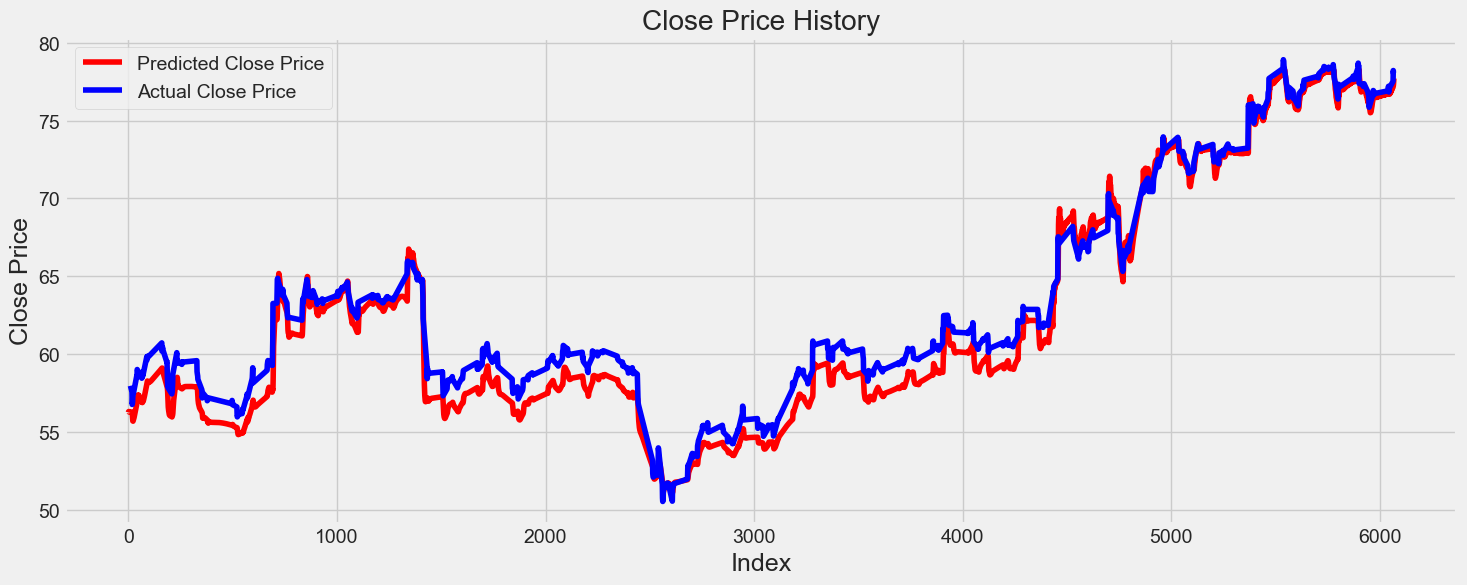

In [46]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df_predictions['Close_predict'], color='red', label='Predicted Close Price')
plt.plot(df_test, color='blue', label='Actual Close Price')
plt.legend()
plt.xlabel('Index', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

+ Đánh giá độ hiệu quả của mô hình bằng các metrics

In [47]:
mae_train = mean_absolute_error(y_train, predictions_train)
rmse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

print("Train Mean Absolute Error:", mae_train)
print("Train Mean Squared Error:", rmse_train)
print("Train R-squared:", r2_train)

Train Mean Absolute Error: 0.893588942444909
Train Mean Squared Error: 2.0565602420804208
Train R-squared: 0.9703810978129837


In [48]:
mae_test = mean_absolute_error(y_test, predictions)
rmse_test = mean_squared_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)

print("Test Mean Absolute Error:", mae_test)
print("Test Mean Squared Error:", rmse_test)
print("Test R-squared:", r2_test)

Test Mean Absolute Error: 1.0252175628405955
Test Mean Squared Error: 1.4051822626413901
Test R-squared: 0.9713627643595786


# Dự đoán

In [49]:
len(test_data_X)

6170

In [50]:
demo_test = test_data_X

In [51]:
x_input = demo_test[-(time_step[0]):]

In [52]:
x_input

array([[2.40485637, 2.3897347 , 2.42058123, 2.41004686, 0.18277131],
       [2.39446198, 2.37950847, 2.40984277, 2.39938686, 0.19302112],
       [2.38406758, 2.36928224, 2.39910431, 2.38872687, 0.20327093],
       [2.39274939, 2.37773251, 2.40566652, 2.39553769, 0.48038309],
       [2.3929391 , 2.37792695, 2.40587449, 2.39574893, 0.47590246],
       [2.3931288 , 2.3781214 , 2.40608246, 2.39596016, 0.47142184],
       [2.3933185 , 2.37831585, 2.40629043, 2.3961714 , 0.46694121],
       [2.3935082 , 2.3785103 , 2.4064984 , 2.39638264, 0.46246059],
       [2.39369791, 2.37870475, 2.40670637, 2.39659388, 0.45797996],
       [2.39388761, 2.3788992 , 2.40691433, 2.39680512, 0.45349934],
       [2.39407731, 2.37909364, 2.4071223 , 2.39701636, 0.44901872],
       [2.39426701, 2.37928809, 2.40733027, 2.39722759, 0.44453809],
       [2.39445671, 2.37948254, 2.40753824, 2.39743883, 0.44005747],
       [2.39464642, 2.37967699, 2.40774621, 2.39765007, 0.43557684],
       [2.39483612, 2.37987144, 2.

In [53]:
x_input = x_input.reshape(time_step[0], 5)

In [54]:
x_input.shape

(100, 5)

+ Tạo ra một dữ liệu test tạm thời

In [55]:
temp_input = list(x_input) 

In [56]:
temp_input_lists = [arr.tolist() for arr in temp_input]

In [57]:
temp_input 

[array([2.40485637, 2.3897347 , 2.42058123, 2.41004686, 0.18277131]),
 array([2.39446198, 2.37950847, 2.40984277, 2.39938686, 0.19302112]),
 array([2.38406758, 2.36928224, 2.39910431, 2.38872687, 0.20327093]),
 array([2.39274939, 2.37773251, 2.40566652, 2.39553769, 0.48038309]),
 array([2.3929391 , 2.37792695, 2.40587449, 2.39574893, 0.47590246]),
 array([2.3931288 , 2.3781214 , 2.40608246, 2.39596016, 0.47142184]),
 array([2.3933185 , 2.37831585, 2.40629043, 2.3961714 , 0.46694121]),
 array([2.3935082 , 2.3785103 , 2.4064984 , 2.39638264, 0.46246059]),
 array([2.39369791, 2.37870475, 2.40670637, 2.39659388, 0.45797996]),
 array([2.39388761, 2.3788992 , 2.40691433, 2.39680512, 0.45349934]),
 array([2.39407731, 2.37909364, 2.4071223 , 2.39701636, 0.44901872]),
 array([2.39426701, 2.37928809, 2.40733027, 2.39722759, 0.44453809]),
 array([2.39445671, 2.37948254, 2.40753824, 2.39743883, 0.44005747]),
 array([2.39464642, 2.37967699, 2.40774621, 2.39765007, 0.43557684]),
 array([2.39483612, 

In [58]:
temp_input = np.array(temp_input)
temp_input.shape

(100, 5)

+ Đưa ra dự đoán cho 24 giờ tiếp theo

In [59]:
def predict_next_24_steps(model, initial_input, n_steps=24):
    predictions = []
    current_input = initial_input.copy() 

    for i in range(n_steps-1):
        if len(current_input.shape) == 2:
            current_input_reshaped = current_input.reshape(1, current_input.shape[0], current_input.shape[1])
        else:
            raise ValueError("current_input must be a 2D array with shape (time_steps, features)")

        next_step_prediction = model.predict(current_input_reshaped)[0, 0] 

        predictions.append(next_step_prediction)

        current_input = np.append(current_input[1:], [[next_step_prediction] + [0]*(current_input.shape[1]-1)], axis=0)

    return predictions

In [60]:
stocks = predict_next_24_steps(model, temp_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [61]:
stocks

[0.6175497,
 0.6025449,
 0.58827794,
 0.574507,
 0.55930614,
 0.54363316,
 0.5303762,
 0.5197244,
 0.51009065,
 0.50202787,
 0.49695444,
 0.49447846,
 0.4936489,
 0.49421656,
 0.49572232,
 0.4977565,
 0.5001891,
 0.5023497,
 0.5035618,
 0.50446457,
 0.50492966,
 0.5031962,
 0.49844047]

In [62]:
print('Biến động cổ phiếu trong 24h tới:')
for i in stocks:
    a = scaler2.inverse_transform(i.reshape(-1, 1))
    print(a - df['Close'][-1])

Biến động cổ phiếu trong 24h tới:
[[-0.51659393]]
[[-1.294281]]
[[-2.0337296]]
[[-2.747467]]
[[-3.5353165]]
[[-4.3476334]]
[[-5.0347366]]
[[-5.5868073]]
[[-6.0861206]]
[[-6.504013]]
[[-6.766968]]
[[-6.895294]]
[[-6.938286]]
[[-6.908867]]
[[-6.830826]]
[[-6.725395]]
[[-6.599312]]
[[-6.4873276]]
[[-6.424507]]
[[-6.377716]]
[[-6.353615]]
[[-6.4434586]]
[[-6.6899414]]
